# Prevendo Ataques de Botnet com IA 


Neste projeto usaremos a técnica de **aprendizado semi-supervisionado** para identificar e prever ataques de botnetsem rede, combinando dados rotulados e não rotulados para aumentar a  precisão  do  modelo.  

O  projeto  envolve  análise  exploratória  de  dados,  pré-processamento, construção e avaliação do modelo de IA. Ao final, o modelo será implementado em um aplicativo web, permitindo a detecção de ameaças e contribuindo para uma resposta ágil e eficiente contra ataques cibernéticos. Criaremos o conjunto de dados dentro do projeto

In [1]:
# Imports
import joblib
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.semi_supervised import LabelSpreading
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

### Carregando os dados

In [2]:
# Define tamanho do dataset
n_samples = 1000

# Semente para reprodução
np.random.seed(42)

# Cria as variáveis independentes
trafego = np.random.normal(1000, 300, n_samples)
duracao_conexao = np.random.normal(60, 20, n_samples)
num_pacotes = np.random.normal(500, 150, n_samples)
bytes_transferidos = np.random.normal(800, 250, n_samples)
num_erros = np.random.randint(0, 50, n_samples)

# Agora, vamos definir uma relação entre os dados e a probabilidade de ser um ataque de botnet:
# - Se o tráfego for alto e a duração for curta, temos uma maior chance de ser botnet
# - Se houver muitos erros, isso pode indicar botnet
# - Se o número de pacotes ou bytes transferidos for muito alto, também pode ser um indicador.

# Probabilidade de ser botnet (0 = normal, 1 = botnet)
status_botnet = []
for i in range(n_samples):
    
    # Base de 10% de probabilidade geral
    prob_botnet = 0.1  
    
    if trafego[i] > 1300 and duracao_conexao[i] < 40:
        prob_botnet += 0.3
    if num_erros[i] > 30:
        prob_botnet += 0.2
    if num_pacotes[i] > 700 or bytes_transferidos[i] > 1000:
        prob_botnet += 0.2
        
    # Atribuir status de botnet com base na probabilidade calculada
    status_botnet.append(1 if np.random.rand() < prob_botnet else 0)

# Criação do dicionário
dados = {
    'trafego': trafego,
    'duracao_conexao': duracao_conexao,
    'num_pacotes': num_pacotes,
    'bytes_transferidos': bytes_transferidos,
    'num_erros': num_erros,
    'status_botnet': status_botnet
}

In [3]:
df = pd.DataFrame(dados)

# deixado parte dos dados sem rotulo para simular dados não rotulados
df['status_botnet'].iloc[:int(n_samples * 0.6)] = -1  # 60% dos dados sem rótulo

## Análise Exploratória

In [4]:
df.head()

,trafego,duracao_conexao,num_pacotes,bytes_transferidos,num_erros,status_botnet
0,1149.014246,87.987109,398.723259,323.048111,23,-1
1,958.520710,78.492674,478.322199,584.903747,9,-1
2,1194.306561,61.192607,381.137012,696.598617,7,-1
3,1456.908957,47.061264,453.805771,1271.921914,20,-1
4,929.753988,73.964466,215.957800,939.138281,5,-1


In [6]:
df.shape

(1000, 6)

In [7]:
df.status_botnet.value_counts()

status_botnet
-1    600
 0    301
 1     99
Name: count, dtype: int64

- Classe 0 = Nao sofreu ataque
- Classe 1 = Sofreu ataque
- Classe -1 = Nao se sabe se sofreu

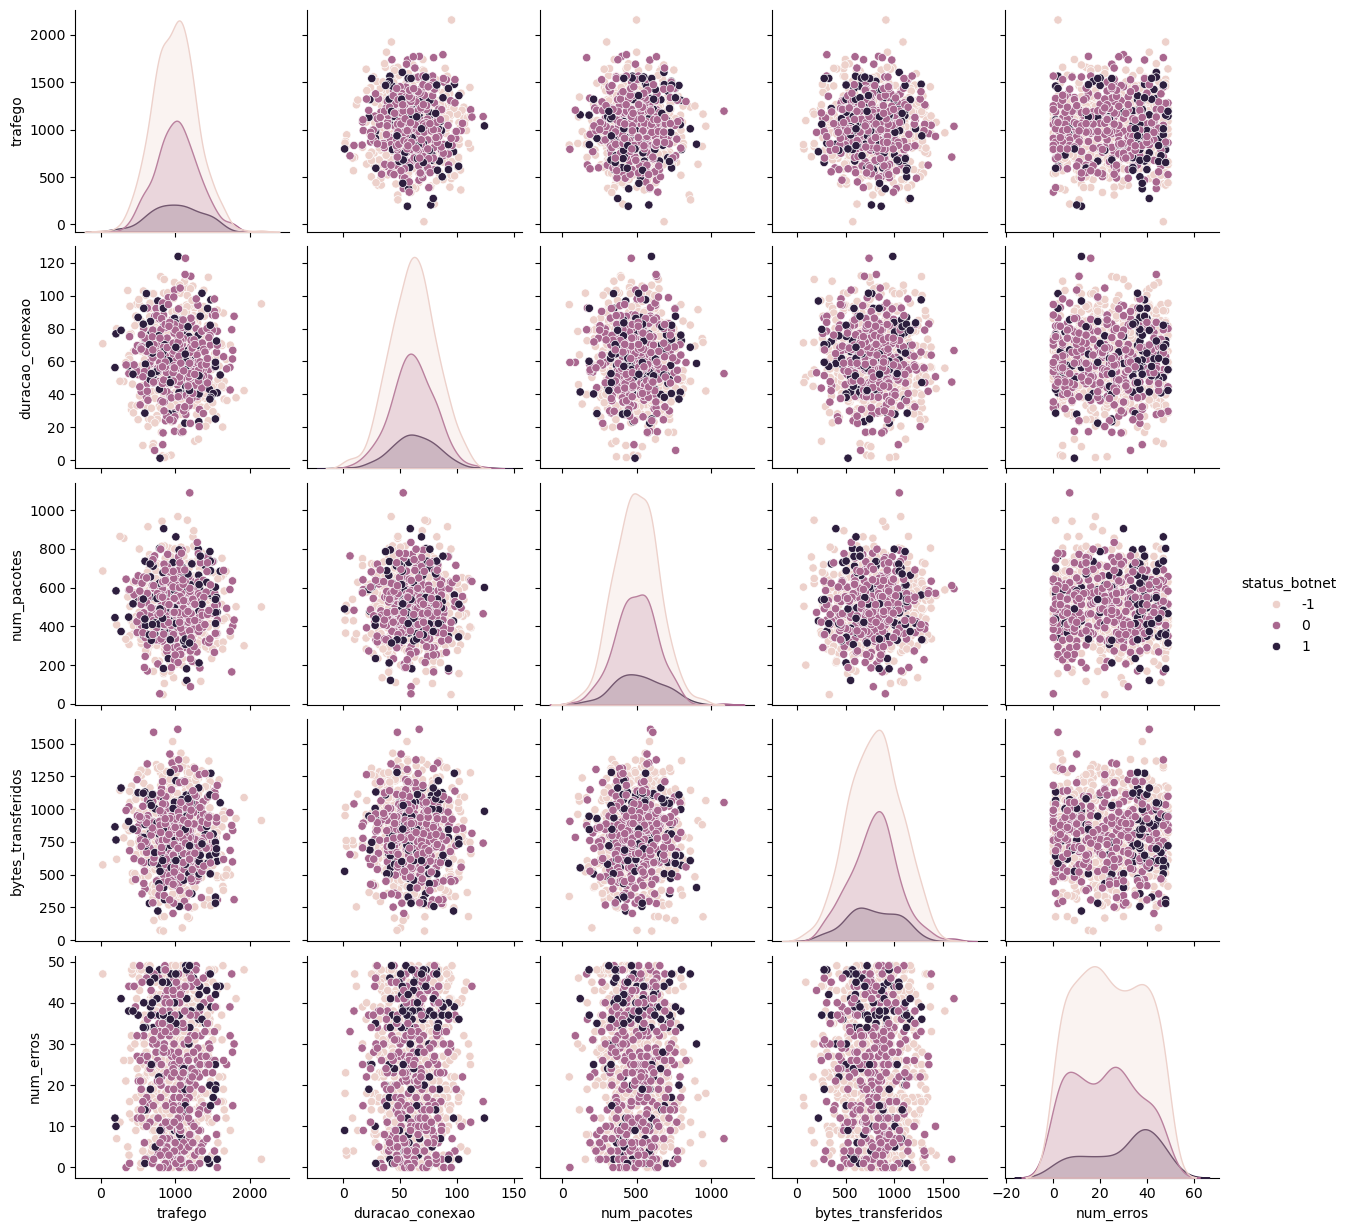

In [8]:
sns.pairplot(df, hue = 'status_botnet', diag_kind = 'kde')
plt.show()

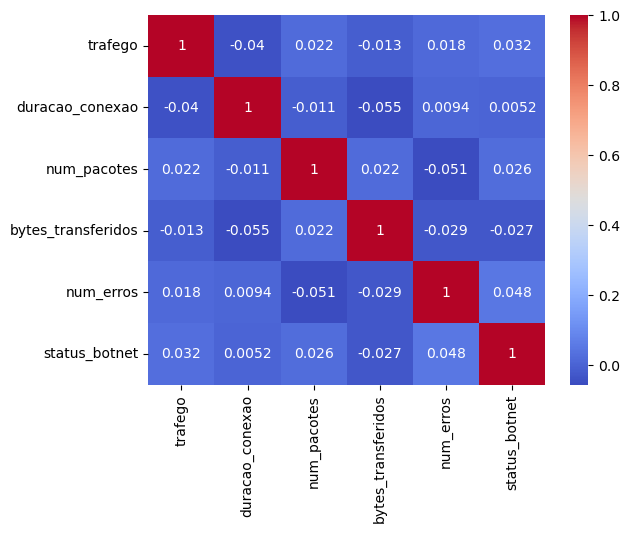

In [9]:
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

## O que fazer quando se tem dados rotulados e nao rotulados?

In [11]:
df.sample(10)

,trafego,duracao_conexao,num_pacotes,bytes_transferidos,num_erros,status_botnet
365,879.633858,56.829409,730.059156,1288.314784,5,-1
645,918.182929,68.566142,382.285714,521.488387,38,0
74,214.076469,79.925336,407.352216,616.741751,7,-1
538,1301.887843,36.601663,313.142394,787.742665,41,-1
49,471.087953,87.601827,523.278603,1099.311731,9,-1
418,1353.789155,90.569369,558.604388,476.843663,19,-1
689,1133.278993,54.821901,591.870319,762.071392,26,0
97,1078.316582,20.035986,339.221415,945.886076,36,-1
394,1353.832036,52.693569,487.484305,1293.135544,2,-1
221,439.820442,66.196414,402.868729,989.373787,49,-1


### Pré processamento de dados

In [ ]:
# Separando os dados rotulados dos não rotulados
labeled_data = df[df['status_botnet'] != -1] 
unlabeled_data = df[df['status_botnet'] == -1]

In [13]:
# Separando X e y
X_labeled = labeled_data.drop(columns = 'status_botnet')
y_labeled = labeled_data['status_botnet']
X_unlabeled = unlabeled_data.drop(columns = 'status_botnet')

- X e y (variavel alvo) para dados rotulados 
- X_unlabled sao os dados nao rotulados

In [14]:
# Dividindo os dados rotulados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_labeled, y_labeled, test_size = 0.2, random_state = 42)

# Normalizando os dados de treino
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [15]:
# Aplicando a normalização nos dados de teste e não rotulados
X_test = scaler.transform(X_test)
X_unlabeled = scaler.transform(X_unlabeled)

## Modelagem (Aprendizado Semi-Supervisionado)

O **Label Spreading** é um algoritmo de aprendizado semi-supervisionado usado para rotular dados não rotulados com base em uma quantidade limitada de dados rotulados. Ele pertence a uma classe de algoritmos de propagação de rótulos, onde a ideia central é propagar os rótulos dos dados rotulados para os não rotulados usando a estrutura dos dados, ou seja, como eles estão relacionados no espaço.

Imagine que você tenha um conjunto de dados onde apenas 10% dos exemplos estão rotulados e 90% não têm rótulos. O Label Spreading tenta usar os 10% de dados rotulados para propagar os rótulos para os 90% restantes, explorando a estrutura do conjunto de dados para inferir as classes dos exemplos não rotulados.

In [ ]:
# Criando o modelo Label Spreading
modelo = LabelSpreading(kernel = 'knn', n_neighbors = 5) # colocar numero impar de vizinhos para evitar empates

# Treinamento
modelo.fit(np.vstack((X_train, X_unlabeled)), np.concatenate((y_train, [-1] * len(X_unlabeled))))

LabelSpreading(kernel='knn', n_neighbors=5)

`modelo.fit(...):`

Essa função ajusta o modelo LabelSpreading, que já foi criado anteriormente, aos dados fornecidos. Aqui, ele está ajustando tanto dados rotulados quanto não rotulados. A ideia é que o modelo utilize os dados rotulados para "disseminar" os rótulos através dos dados não rotulados, com base em similaridades.

`np.vstack((X_train, X_unlabeled)):`

np.vstack empilha os arrays verticalmente, ou seja, ele concatena X_train (os dados de treinamento rotulados) com X_unlabeled (os dados não rotulados).

X_train são os dados de entrada já conhecidos, com seus respectivos rótulos, enquanto X_unlabeled são os dados de entrada cuja classe o modelo deve inferir.

O resultado é um conjunto de dados que inclui tanto os exemplos rotulados quanto os não rotulados.

`np.concatenate((y_train, [-1] * len(X_unlabeled))):`

np.concatenate concatena arrays. Aqui, ele concatena os rótulos y_train (rótulos dos dados de treinamento) com um array de -1, que é criado da seguinte forma:

[-1] * len(X_unlabeled) cria uma lista de -1s, com o mesmo comprimento que X_unlabeled. O valor -1 é utilizado para marcar os dados não rotulados, indicando ao modelo que esses exemplos não têm um rótulo conhecido.

O resultado é um array de rótulos que inclui os rótulos conhecidos para os dados de treinamento e -1 para os dados não rotulados.

### Como Funciona a Previsão Para Esse Tipo de Modelo?

Propagação de rótulos: O Label Spreading utiliza a similaridade dos dados para propagar os rótulos dos exemplos rotulados para os não rotulados. Quando você usa predict, o modelo vai atribuir o rótulo de maior probabilidade ao dado de entrada.

No caso de dados de teste: O modelo tenta classificar os exemplos de teste da mesma forma como fez durante o treinamento, propagando rótulos com base na similaridade com os exemplos que viu no treinamento.

### Avaliação do modelo

In [18]:
# Avaliando no conjunto de teste
y_pred = modelo.predict(X_test)
print("Acurácia:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Acurácia: 0.775
              precision    recall  f1-score   support

           0       0.83      0.89      0.86        62
           1       0.50      0.39      0.44        18

    accuracy                           0.78        80
   macro avg       0.67      0.64      0.65        80
weighted avg       0.76      0.78      0.76        80



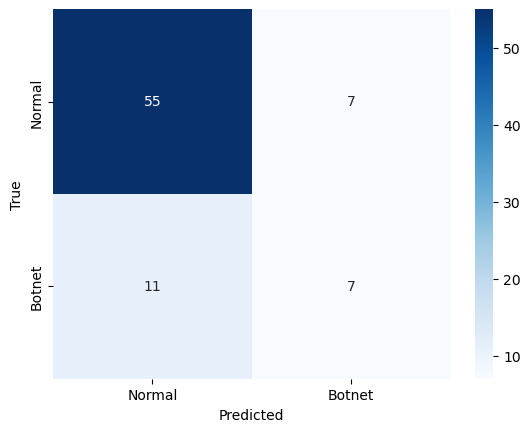

In [22]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "Botnet"], yticklabels=["Normal", "Botnet"])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### Salvando

In [21]:
joblib.dump(scaler, 'modelos/scaler.pkl')
joblib.dump(modelo, 'modelos/botnet_detector_model.pkl')

['modelos/botnet_detector_model.pkl']